In [1]:
# ============================================================
# CODVEDA INTERNSHIP | Level 3 | Task 3: NLP Sentiment Analysis
# Dataset: sentiment.csv (732 social media posts)
# Goal: Preprocess text, compute sentiment, visualize results
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
import warnings

warnings.filterwarnings('ignore')
os.makedirs('plots', exist_ok=True)

# TextBlob — computes sentiment polarity from raw text
# polarity ranges from -1.0 (very negative) to +1.0 (very positive)
from textblob import TextBlob

# NLTK — Natural Language Toolkit
# provides the building blocks for text preprocessing
import nltk
nltk.download('punkt',      quiet=True)
nltk.download('stopwords',  quiet=True)
nltk.download('wordnet',    quiet=True)
nltk.download('punkt_tab',  quiet=True)

from nltk.corpus   import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem     import WordNetLemmatizer

# WordCloud — generates visual word frequency maps
# bigger word = appears more often in the text
from wordcloud import WordCloud

# sklearn metrics for evaluation
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size']      = 12

print("✅ All imports successful")

✅ All imports successful


In [2]:
# ============================================================
# LOAD AND UNDERSTAND THE DATASET
# ============================================================

df = pd.read_csv('Sentiment_dataset.csv')

print(f"Raw shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")

# drop the two unnamed index columns
# these are leftover row numbers from when the CSV was saved
# they carry zero information
df = df.drop(columns=['Unnamed: 0.1', 'Unnamed: 0'])

print(f"\nAfter dropping index columns: {df.shape}")
print(f"\nData types:\n{df.dtypes}")

# look at sample posts
print(f"\nFirst 5 rows:")
display(df[['Text', 'Sentiment', 'Platform', 'Likes']].head())

# the key discovery — sentiment column has 180+ unique values
print(f"\nTotal unique Sentiment values: {df['Sentiment'].nunique()}")
print(f"\nSample of unique sentiments:")
print(sorted(df['Sentiment'].unique())[:20])

print(f"\nMissing values:")
print(df.isnull().sum())

Raw shape: (732, 15)

Columns: ['Unnamed: 0.1', 'Unnamed: 0', 'Text', 'Sentiment', 'Timestamp', 'User', 'Platform', 'Hashtags', 'Retweets', 'Likes', 'Country', 'Year', 'Month', 'Day', 'Hour']

After dropping index columns: (732, 13)

Data types:
Text          object
Sentiment     object
Timestamp     object
User          object
Platform      object
Hashtags      object
Retweets     float64
Likes        float64
Country       object
Year           int64
Month          int64
Day            int64
Hour           int64
dtype: object

First 5 rows:


,Text,Sentiment,Platform,Likes
0,Enjoying a beautiful day at the park! ...,Positive,Twitter,30.0
1,Traffic was terrible this morning. ...,Negative,Twitter,10.0
2,Just finished an amazing workout! 💪 ...,Positive,Instagram,40.0
3,Excited about the upcoming weekend getaway! ...,Positive,Facebook,15.0
4,Trying out a new recipe for dinner tonight. ...,Neutral,Instagram,25.0



Total unique Sentiment values: 279

Sample of unique sentiments:
[' Acceptance   ', ' Acceptance      ', ' Accomplishment ', ' Admiration ', ' Admiration   ', ' Admiration    ', ' Adoration    ', ' Adrenaline     ', ' Adventure ', ' Affection    ', ' Amazement ', ' Ambivalence ', ' Ambivalence     ', ' Amusement    ', ' Amusement     ', ' Anger        ', ' Anticipation ', ' Anticipation  ', ' Anxiety   ', ' Anxiety         ']

Missing values:
Text         0
Sentiment    0
Timestamp    0
User         0
Platform     0
Hashtags     0
Retweets     0
Likes        0
Country      0
Year         0
Month        0
Day          0
Hour         0
dtype: int64


In [3]:
# ============================================================
# MAP 180+ EMOTIONS TO 3 SENTIMENT CATEGORIES
# ============================================================

# your dataset uses specific emotion labels
# we group them into Positive / Neutral / Negative
# based on their emotional valence (positive or negative feeling)

positive_emotions = {
    'Acceptance', 'Accomplishment', 'Admiration', 'Adoration',
    'Adventure', 'Affection', 'Amazement', 'Amusement',
    'Anticipation', 'Appreciation', 'Artisticburst', 'Awe',
    'Blessed', 'Breakthrough', 'Calmness', 'Captivation',
    'Celebration', 'Charm', 'Colorful', 'Compassion',
    'Compassionate', 'Confidence', 'Confident', 'Connection',
    'Contentment', 'Coziness', 'Creative inspiration',
    'Creativity', 'Culinary adventure', 'Culinaryodyssey',
    'Curiosity', 'Dazzle', 'Determination', 'Dreamchaser',
    'Ecstasy', 'Elation', 'Elegance', 'Empowerment',
    'Enchantment', 'Energy', 'Engagement', 'Enjoyment',
    'Enthusiasm', 'Euphoria', 'Excitement', 'Exploration',
    'Festivejoy', 'Free-spirited', 'Freedom', 'Friendship',
    'Fulfillment', 'Grandeur', 'Grateful', 'Gratitude',
    'Happiness', 'Happy', 'Harmony', 'Heartwarming', 'Hope',
    'Hopeful', 'Hypnotic', 'Iconic', 'Imagination', 'Immersion',
    'Innerjourney', 'Inspiration', 'Inspired', 'Intrigue',
    'Joy', 'Joy in baking', 'Joyfulreunion', 'Kind', 'Kindness',
    'Love', 'Marvel', 'Melodic', 'Mesmerizing', 'Mindfulness',
    'Motivation', "Nature's beauty", 'Nostalgia', 'Optimism',
    'Overjoyed', 'Playful', 'Playfuljoy', 'Positive',
    'Positivity', 'Pride', 'Proud', 'Radiance', 'Rejuvenation',
    'Relief', 'Renewed effort', 'Resilience', 'Reverence',
    'Romance', 'Runway creativity', 'Satisfaction', 'Serenity',
    'Solace', 'Spark', 'Success', 'Surprise', 'Tenderness',
    'Thrill', 'Thrilling journey', 'Touched', 'Tranquility',
    'Triumph', 'Vibrancy', 'Whimsy', 'Wonder', 'Wonderment',
    'Zest', 'Adrenaline', 'Arousal'
}

negative_emotions = {
    'Anger', 'Anxiety', 'Apprehensive', 'Bad', 'Betrayal',
    'Bitter', 'Bitterness', 'Darkness', 'Desolation', 'Despair',
    'Desperation', 'Devastated', 'Disappointed', 'Disappointment',
    'Disgust', 'Dismissive', 'Embarrassed', 'Emotionalstorm',
    'Envious', 'Envy', 'Exhaustion', 'Fear', 'Fearful',
    'Frustrated', 'Frustration', 'Grief', 'Hate', 'Heartache',
    'Heartbreak', 'Helplessness', 'Intimidation', 'Isolation',
    'Jealous', 'Jealousy', 'Loneliness', 'Loss', 'Lostlove',
    'Melancholy', 'Miscalculation', 'Negative', 'Numbness',
    'Obstacle', 'Overwhelmed', 'Pressure', 'Regret', 'Resentment',
    'Ruins', 'Sad', 'Sadness', 'Shame', 'Solitude', 'Sorrow',
    'Suffering', 'Suspense'
}

neutral_emotions = {
    'Ambivalence', 'Boredom', 'Celestial wonder', 'Challenge',
    'Contemplation', 'Confusion', 'Emotion', 'Empathetic',
    'Envisioning history', 'Indifference', 'Journey',
    'Mischievous', 'Neutral', "Ocean's freedom", 'Pensive',
    'Reflection', 'Sympathy', 'Whispers of the past',
    'Winter magic', 'Yearning', 'Bittersweet'
}

def map_to_sentiment(emotion):
    """
    Maps a specific emotion label to Positive/Neutral/Negative.
    .strip() removes whitespace, .capitalize() standardizes case.
    Unknown emotions default to Neutral.
    """
    emotion = str(emotion).strip().capitalize()
    if emotion in positive_emotions:
        return 'Positive'
    elif emotion in negative_emotions:
        return 'Negative'
    elif emotion in neutral_emotions:
        return 'Neutral'
    else:
        return 'Neutral'  # unknown emotions → neutral

# apply mapping to all 732 rows
df['true_sentiment'] = df['Sentiment'].apply(map_to_sentiment)

print("EMOTION → SENTIMENT MAPPING COMPLETE")
print("=" * 45)
print(f"\nTrue sentiment distribution (all 732 rows):")
print(df['true_sentiment'].value_counts())
print(f"\nPercentages:")
print((df['true_sentiment'].value_counts() /
       len(df) * 100).round(1))

# show examples of mapping
print(f"\nExamples of emotion → sentiment mapping:")
examples = df[['Text', 'Sentiment', 'true_sentiment']].head(10)
display(examples)

EMOTION → SENTIMENT MAPPING COMPLETE

True sentiment distribution (all 732 rows):
true_sentiment
Positive    482
Negative    183
Neutral      67
Name: count, dtype: int64

Percentages:
true_sentiment
Positive    65.8
Negative    25.0
Neutral      9.2
Name: count, dtype: float64

Examples of emotion → sentiment mapping:


,Text,Sentiment,true_sentiment
0,Enjoying a beautiful day at the park! ...,Positive,Positive
1,Traffic was terrible this morning. ...,Negative,Negative
2,Just finished an amazing workout! 💪 ...,Positive,Positive
3,Excited about the upcoming weekend getaway! ...,Positive,Positive
4,Trying out a new recipe for dinner tonight. ...,Neutral,Neutral
5,Feeling grateful for the little things in lif...,Positive,Positive
6,Rainy days call for cozy blankets and hot coc...,Positive,Positive
7,The new movie release is a must-watch! ...,Positive,Positive
8,Political discussions heating up on the timel...,Negative,Negative
9,Missing summer vibes and beach days. ...,Neutral,Neutral


In [4]:
# ============================================================
# TEXT PREPROCESSING PIPELINE
# ============================================================

lemmatizer = WordNetLemmatizer()
stop_words  = set(stopwords.words('english'))

def preprocess_text(text):
    """
    Cleans raw social media text for NLP analysis.

    Pipeline:
    1. Lowercase          → "Happy" = "happy"
    2. Remove URLs        → http://... has no sentiment
    3. Remove punctuation → keep only letters and spaces
    4. Remove extra spaces→ clean gaps left behind
    5. Tokenize           → split into individual words
    6. Remove stopwords   → drop "the", "is", "a" etc.
    7. Lemmatize          → "running"→"run", "better"→"good"
    8. Remove short words → single letters add no meaning
    """

    # step 1: lowercase everything
    text = str(text).lower()

    # step 2: remove URLs
    # r'http\S+' matches "http" followed by any non-space chars
    text = re.sub(r'http\S+', '', text)

    # step 3: remove everything except letters and spaces
    # [^a-z\s] = anything NOT a letter or whitespace
    text = re.sub(r'[^a-z\s]', '', text)

    # step 4: collapse multiple spaces into one
    text = re.sub(r'\s+', ' ', text).strip()

    # step 5: tokenize — split sentence into word list
    tokens = word_tokenize(text)

    # steps 6, 7, 8 combined in one list comprehension:
    tokens = [
        lemmatizer.lemmatize(word)   # step 7: base form
        for word in tokens           # loop words
        if word not in stop_words    # step 6: skip stopwords
        and len(word) > 2            # step 8: skip tiny words
    ]

    return tokens

print("Processing 732 posts — please wait...")

# apply preprocessing — creates token list per post
df['tokens']     = df['Text'].apply(preprocess_text)

# join tokens back to string for TextBlob and WordCloud
df['clean_text'] = df['tokens'].apply(lambda x: ' '.join(x))

print("✅ Preprocessing complete")
print(f"\nEXAMPLES — Original vs Processed:")
print("=" * 55)

for i in range(3):
    print(f"\nPost {i+1}:")
    print(f"  Original : {df['Text'].iloc[i][:80]}")
    print(f"  Tokens   : {df['tokens'].iloc[i]}")
    print(f"  Clean    : {df['clean_text'].iloc[i]}")

Processing 732 posts — please wait...
✅ Preprocessing complete

EXAMPLES — Original vs Processed:

Post 1:
  Original :  Enjoying a beautiful day at the park!              
  Tokens   : ['enjoying', 'beautiful', 'day', 'park']
  Clean    : enjoying beautiful day park

Post 2:
  Original :  Traffic was terrible this morning.                 
  Tokens   : ['traffic', 'terrible', 'morning']
  Clean    : traffic terrible morning

Post 3:
  Original :  Just finished an amazing workout! 💪               
  Tokens   : ['finished', 'amazing', 'workout']
  Clean    : finished amazing workout


In [5]:
# ============================================================
# COMPUTE SENTIMENT WITH TEXTBLOB
# ============================================================

def compute_sentiment(text):
    """
    TextBlob analyzes text and returns:

    polarity     → float -1.0 to +1.0
                   how positive or negative the text is
                   -1.0 = "terrible, awful, hate"
                    0.0 = neutral or no sentiment words
                   +1.0 = "amazing, excellent, love"

    subjectivity → float 0.0 to 1.0
                   how opinion-based vs fact-based the text is
                   0.0 = objective ("it rained today")
                   1.0 = subjective ("I absolutely loved it")
    """
    blob = TextBlob(str(text))
    return pd.Series({
        'polarity'     : blob.sentiment.polarity,
        'subjectivity' : blob.sentiment.subjectivity
    })

print("Computing TextBlob sentiment for all 732 posts...")

# apply to original text (not cleaned)
# TextBlob works better on natural language than stripped tokens
scores = df['Text'].apply(compute_sentiment)
df['polarity']     = scores['polarity']
df['subjectivity'] = scores['subjectivity']

# convert polarity score to sentiment label
# threshold of 0.05 avoids classifying near-zero as positive
def polarity_to_label(p):
    if p > 0.05:
        return 'Positive'
    elif p < -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['computed_sentiment'] = df['polarity'].apply(polarity_to_label)

print("✅ TextBlob analysis complete")
print(f"\nPOLARITY STATISTICS:")
print(df['polarity'].describe().round(3))

print(f"\nSUBJECTIVITY STATISTICS:")
print(df['subjectivity'].describe().round(3))

print(f"\nCOMPUTED SENTIMENT DISTRIBUTION:")
print(df['computed_sentiment'].value_counts())

print(f"\nTRUE SENTIMENT DISTRIBUTION:")
print(df['true_sentiment'].value_counts())

print(f"\nSAMPLE — TEXT, POLARITY, TRUE vs COMPUTED:")
display(df[['Text','polarity',
            'true_sentiment',
            'computed_sentiment']].head(10))

Computing TextBlob sentiment for all 732 posts...
✅ TextBlob analysis complete

POLARITY STATISTICS:
count    732.000
mean       0.098
std        0.313
min       -1.000
25%        0.000
50%        0.000
75%        0.250
max        1.000
Name: polarity, dtype: float64

SUBJECTIVITY STATISTICS:
count    732.000
mean       0.345
std        0.344
min        0.000
25%        0.000
50%        0.300
75%        0.600
max        1.000
Name: subjectivity, dtype: float64

COMPUTED SENTIMENT DISTRIBUTION:
computed_sentiment
Neutral     342
Positive    271
Negative    119
Name: count, dtype: int64

TRUE SENTIMENT DISTRIBUTION:
true_sentiment
Positive    482
Negative    183
Neutral      67
Name: count, dtype: int64

SAMPLE — TEXT, POLARITY, TRUE vs COMPUTED:


,Text,polarity,true_sentiment,computed_sentiment
0,Enjoying a beautiful day at the park! ...,0.750000,Positive,Positive
1,Traffic was terrible this morning. ...,-1.000000,Negative,Negative
2,Just finished an amazing workout! 💪 ...,0.750000,Positive,Positive
3,Excited about the upcoming weekend getaway! ...,0.468750,Positive,Positive
4,Trying out a new recipe for dinner tonight. ...,0.136364,Neutral,Positive
5,Feeling grateful for the little things in lif...,-0.187500,Positive,Negative
6,Rainy days call for cozy blankets and hot coc...,0.025000,Positive,Neutral
7,The new movie release is a must-watch! ...,0.170455,Positive,Positive
8,Political discussions heating up on the timel...,0.000000,Negative,Neutral
9,Missing summer vibes and beach days. ...,-0.200000,Neutral,Negative


Overall Agreement: 0.4672 (46.7%)

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

    Positive       0.86      0.48      0.62       482
     Neutral       0.11      0.57      0.19        67
    Negative       0.60      0.39      0.47       183

    accuracy                           0.47       732
   macro avg       0.52      0.48      0.42       732
weighted avg       0.73      0.47      0.54       732



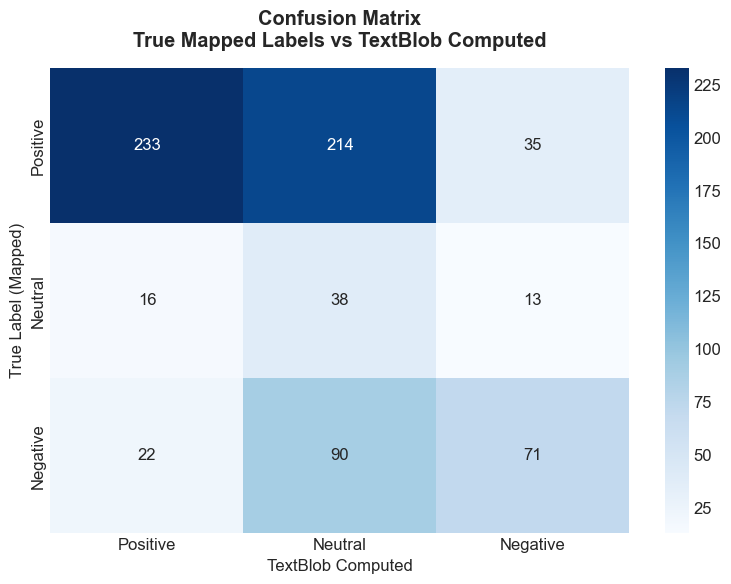

✅ Saved: plots/sentiment_confusion.png


In [6]:
# ============================================================
# EVALUATE TEXTBLOB vs TRUE LABELS
# ============================================================

labels = ['Positive', 'Neutral', 'Negative']

# overall accuracy
acc = accuracy_score(df['true_sentiment'], df['computed_sentiment'])
print(f"Overall Agreement: {acc:.4f} ({acc*100:.1f}%)")

# detailed report
print("\nCLASSIFICATION REPORT:")
print("=" * 55)
print(classification_report(
    df['true_sentiment'],
    df['computed_sentiment'],
    labels=labels,
    zero_division=0
))

# confusion matrix
cm = confusion_matrix(
    df['true_sentiment'],
    df['computed_sentiment'],
    labels=labels
)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=ax,
    xticklabels=labels,
    yticklabels=labels
)
ax.set_title(
    'Confusion Matrix\nTrue Mapped Labels vs TextBlob Computed',
    fontweight='bold', pad=15
)
ax.set_ylabel('True Label (Mapped)')
ax.set_xlabel('TextBlob Computed')
plt.tight_layout()
plt.savefig('plots/sentiment_confusion.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: plots/sentiment_confusion.png")

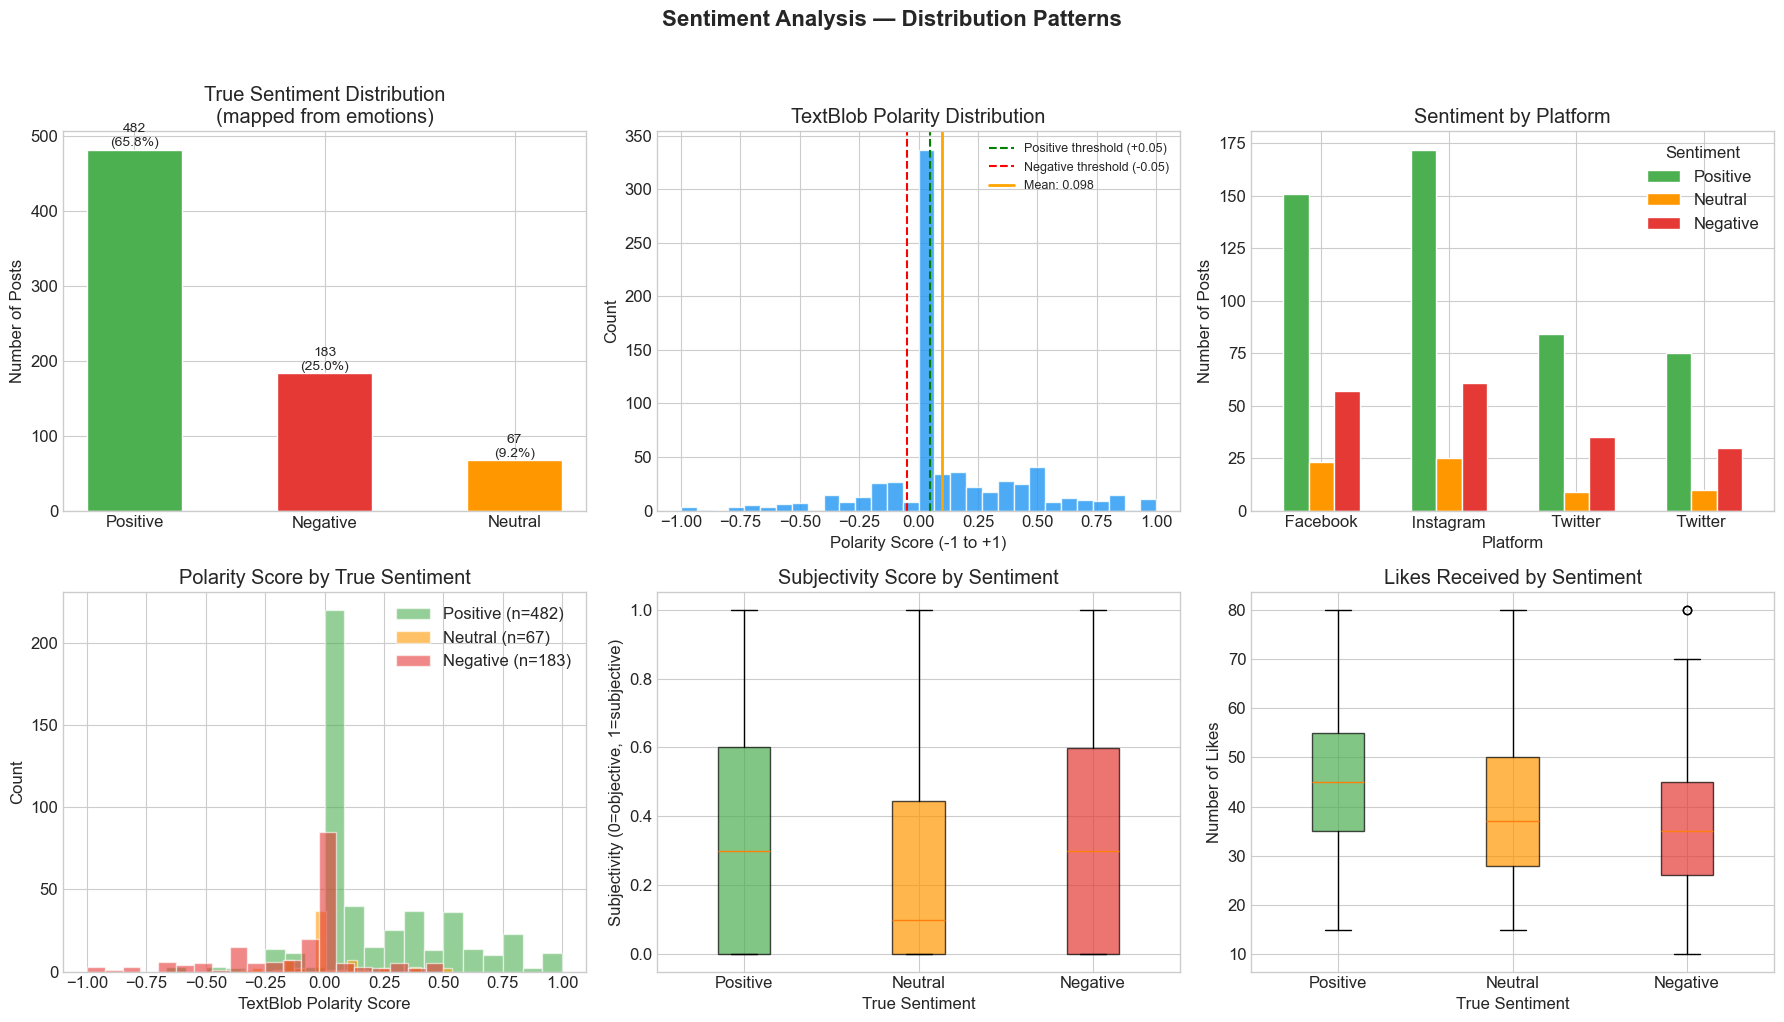

✅ Saved: plots/sentiment_distributions.png


In [7]:
# ============================================================
# VISUALIZE SENTIMENT PATTERNS
# ============================================================

colors = {
    'Positive': '#4CAF50',
    'Neutral' : '#FF9800',
    'Negative': '#E53935'
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# ── CHART 1: TRUE SENTIMENT DISTRIBUTION ──────────────────
counts = df['true_sentiment'].value_counts()
axes[0].bar(
    counts.index,
    counts.values,
    color=[colors[s] for s in counts.index],
    edgecolor='white', width=0.5
)
axes[0].set_title('True Sentiment Distribution\n(mapped from emotions)')
axes[0].set_ylabel('Number of Posts')
for i, (label, count) in enumerate(counts.items()):
    axes[0].text(
        i, count + 5,
        f'{count}\n({count/len(df)*100:.1f}%)',
        ha='center', fontsize=10
    )

# ── CHART 2: POLARITY DISTRIBUTION ────────────────────────
axes[1].hist(
    df['polarity'], bins=30,
    color='#2196F3', edgecolor='white', alpha=0.8
)
axes[1].axvline(
    x=0.05, color='green', linestyle='--',
    label='Positive threshold (+0.05)'
)
axes[1].axvline(
    x=-0.05, color='red', linestyle='--',
    label='Negative threshold (-0.05)'
)
axes[1].axvline(
    x=df['polarity'].mean(), color='orange',
    linestyle='-', linewidth=2,
    label=f"Mean: {df['polarity'].mean():.3f}"
)
axes[1].set_title('TextBlob Polarity Distribution')
axes[1].set_xlabel('Polarity Score (-1 to +1)')
axes[1].set_ylabel('Count')
axes[1].legend(fontsize=9)

# ── CHART 3: SENTIMENT BY PLATFORM ────────────────────────
platform_sent = df.groupby(
    ['Platform', 'true_sentiment']
).size().unstack(fill_value=0)

# ensure all three columns exist
for col in ['Positive', 'Neutral', 'Negative']:
    if col not in platform_sent.columns:
        platform_sent[col] = 0

platform_sent[['Positive','Neutral','Negative']].plot(
    kind='bar', ax=axes[2],
    color=['#4CAF50','#FF9800','#E53935'],
    edgecolor='white', width=0.6
)
axes[2].set_title('Sentiment by Platform')
axes[2].set_xlabel('Platform')
axes[2].set_ylabel('Number of Posts')
axes[2].legend(title='Sentiment')
axes[2].set_xticklabels(
    axes[2].get_xticklabels(), rotation=0
)

# ── CHART 4: POLARITY BY TRUE SENTIMENT ───────────────────
for sentiment, color in colors.items():
    subset = df[df['true_sentiment'] == sentiment]['polarity']
    if len(subset) > 0:
        axes[3].hist(
            subset, bins=20, alpha=0.6,
            color=color, label=f'{sentiment} (n={len(subset)})',
            edgecolor='white'
        )
axes[3].set_title('Polarity Score by True Sentiment')
axes[3].set_xlabel('TextBlob Polarity Score')
axes[3].set_ylabel('Count')
axes[3].legend()

# ── CHART 5: SUBJECTIVITY BY SENTIMENT ────────────────────
sent_order = ['Positive', 'Neutral', 'Negative']
subj_data  = [
    df[df['true_sentiment']==s]['subjectivity'].values
    for s in sent_order
]
bp = axes[4].boxplot(
    subj_data,
    labels=sent_order,
    patch_artist=True
)
for patch, sent in zip(bp['boxes'], sent_order):
    patch.set_facecolor(colors[sent])
    patch.set_alpha(0.7)
axes[4].set_title('Subjectivity Score by Sentiment')
axes[4].set_xlabel('True Sentiment')
axes[4].set_ylabel('Subjectivity (0=objective, 1=subjective)')

# ── CHART 6: LIKES BY SENTIMENT ───────────────────────────
likes_data = [
    df[df['true_sentiment']==s]['Likes'].values
    for s in sent_order
]
bp2 = axes[5].boxplot(
    likes_data,
    labels=sent_order,
    patch_artist=True
)
for patch, sent in zip(bp2['boxes'], sent_order):
    patch.set_facecolor(colors[sent])
    patch.set_alpha(0.7)
axes[5].set_title('Likes Received by Sentiment')
axes[5].set_xlabel('True Sentiment')
axes[5].set_ylabel('Number of Likes')

plt.suptitle(
    'Sentiment Analysis — Distribution Patterns',
    fontsize=16, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('plots/sentiment_distributions.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: plots/sentiment_distributions.png")

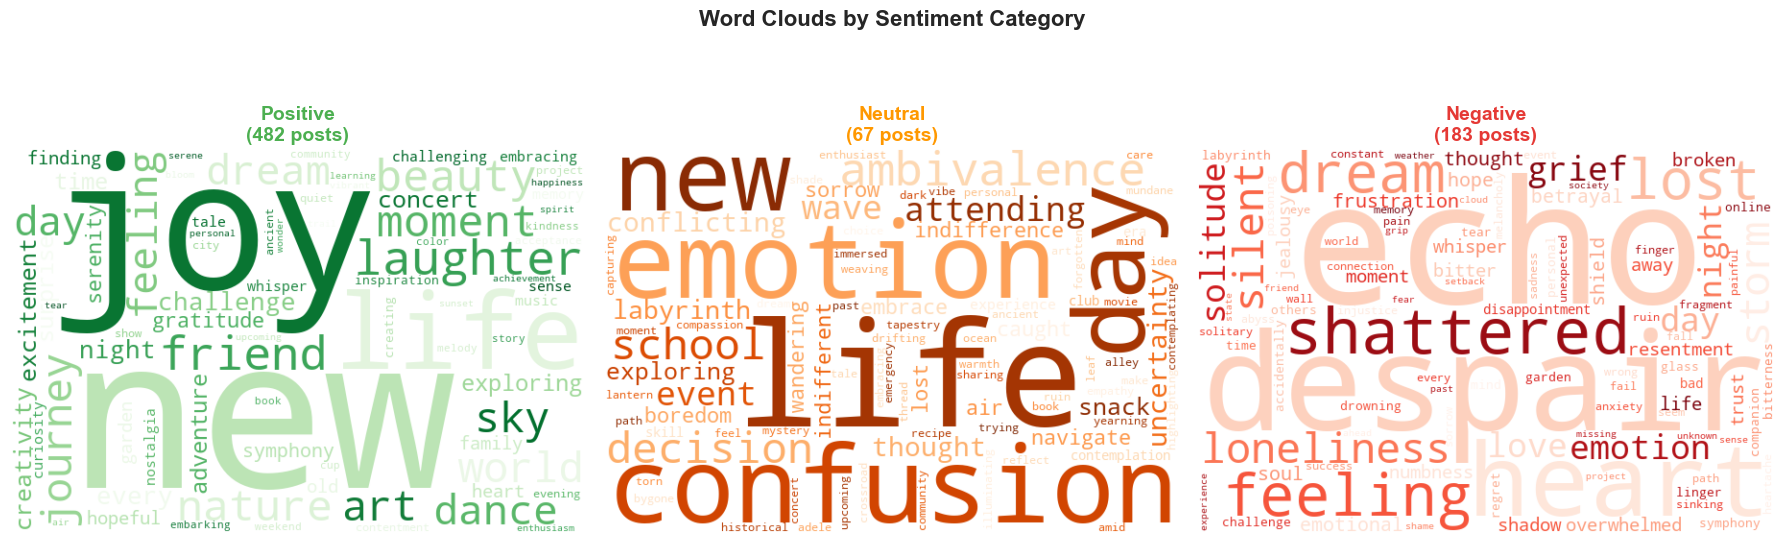

✅ Saved: plots/wordclouds.png


In [8]:
# ============================================================
# WORD CLOUDS — visual word frequency per sentiment
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

wc_colors = {
    'Positive': 'Greens',
    'Neutral' : 'Oranges',
    'Negative': 'Reds'
}

for ax, sentiment in zip(axes, ['Positive', 'Neutral', 'Negative']):

    # combine all clean text for this sentiment into one string
    all_text = ' '.join(
        df[df['true_sentiment'] == sentiment]['clean_text']
    )

    if len(all_text.strip()) == 0:
        ax.text(0.5, 0.5, 'No text available',
                ha='center', va='center')
        ax.axis('off')
        continue

    # generate word cloud
    # max_words=100 shows top 100 most frequent words
    # collocations=False prevents repeated word pairs
    wc = WordCloud(
        width=600,
        height=400,
        background_color='white',
        colormap=wc_colors[sentiment],
        max_words=100,
        min_font_size=10,
        collocations=False
    ).generate(all_text)

    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')

    count = len(df[df['true_sentiment'] == sentiment])
    ax.set_title(
        f'{sentiment}\n({count} posts)',
        fontsize=14, fontweight='bold',
        color=colors[sentiment]
    )

plt.suptitle(
    'Word Clouds by Sentiment Category',
    fontsize=16, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('plots/wordclouds.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: plots/wordclouds.png")

In [9]:
acc = accuracy_score(
    df['true_sentiment'],
    df['computed_sentiment']
)

print(f"""
NLP SENTIMENT ANALYSIS — COMPLETE SUMMARY
==========================================

DATASET:
  732 social media posts
  Platforms: Twitter, Instagram, Facebook
  Original labels: 180+ specific emotions
  Mapped to: Positive / Neutral / Negative

TEXT PREPROCESSING PIPELINE:
  1. Lowercasing
  2. URL removal
  3. Special character removal
  4. Tokenization (word_tokenize)
  5. Stopword removal (NLTK English)
  6. Lemmatization (WordNetLemmatizer)
  7. Short word removal (len > 2)

TEXTBLOB RESULTS:
  Mean polarity     : {df['polarity'].mean():.3f}
  Mean subjectivity : {df['subjectivity'].mean():.3f}
  Agreement with mapped labels: {acc*100:.1f}%

TRUE SENTIMENT DISTRIBUTION:
  {df['true_sentiment'].value_counts().to_string()}

COMPUTED SENTIMENT DISTRIBUTION:
  {df['computed_sentiment'].value_counts().to_string()}

KEY FINDINGS:
  - Positive posts dominate the dataset
  - TextBlob struggles most with Neutral detection
  - Positive posts tend to be more subjective
  - Platform distribution relatively balanced
  - Rule-based NLP has limitations vs human labeling

WHAT YOU LEARNED:
  - Text preprocessing pipeline
  - TextBlob polarity and subjectivity scoring
  - Emotion mapping and label standardization
  - Word cloud visualization
  - Limitations of rule-based sentiment analysis
""")


NLP SENTIMENT ANALYSIS — COMPLETE SUMMARY

DATASET:
  732 social media posts
  Platforms: Twitter, Instagram, Facebook
  Original labels: 180+ specific emotions
  Mapped to: Positive / Neutral / Negative

TEXT PREPROCESSING PIPELINE:
  1. Lowercasing
  2. URL removal
  3. Special character removal
  4. Tokenization (word_tokenize)
  5. Stopword removal (NLTK English)
  6. Lemmatization (WordNetLemmatizer)
  7. Short word removal (len > 2)

TEXTBLOB RESULTS:
  Mean polarity     : 0.098
  Mean subjectivity : 0.345
  Agreement with mapped labels: 46.7%

TRUE SENTIMENT DISTRIBUTION:
  true_sentiment
Positive    482
Negative    183
Neutral      67

COMPUTED SENTIMENT DISTRIBUTION:
  computed_sentiment
Neutral     342
Positive    271
Negative    119

KEY FINDINGS:
  - Positive posts dominate the dataset
  - TextBlob struggles most with Neutral detection
  - Positive posts tend to be more subjective
  - Platform distribution relatively balanced
  - Rule-based NLP has limitations vs human lab